## Propriedades da lâmina

In [4]:
import openslide, kfbslide
from pathlib import Path

s = kfbslide.OpenSlide(Path(r"D:\2024-10-14_08_20_41CYT.kfb"))
print(s.dimensions, s.level_count, s.level_downsamples)
print(s.properties[openslide.PROPERTY_NAME_MPP_X])

(83704, 80034) 6 (1.0, 2.0, 4.0, 8.0, 16.0, 32.0)
0.24660246074199677


In [5]:
for k in ("openslide.objective-power", "openslide.vendor",
          "openslide.mpp-x", "openslide.mpp-y"):
    print(k, s.properties.get(k))

for i, (dim, ds) in enumerate(zip(s.level_dimensions, s.level_downsamples)):
    print(i, dim, round(ds,3), round(float(s.properties["openslide.mpp-x"])*ds, 3), "µm/px")

openslide.objective-power 40
openslide.vendor kfbio
openslide.mpp-x 0.24660246074199677
openslide.mpp-y 0.24660246074199677
0 (83704, 80034) 1.0 0.247 µm/px
1 (41852, 40017) 2.0 0.493 µm/px
2 (20926, 20008) 4.0 0.986 µm/px
3 (10463, 10004) 8.0 1.973 µm/px
4 (5231, 5002) 16.0 3.946 µm/px
5 (2615, 2501) 32.0 7.891 µm/px


## Setup

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu

In [8]:
level = 1                     
ds = int(s.level_downsamples[level])
tile_size = 224
step = tile_size * ds              
W, H = s.dimensions

print("[level]", level)
print("[ds]", ds)
print("[tile_size]", tile_size)
print("[step]", step)
print("[dimensions]", "Width:", W, "Height:", H)

[level] 1
[ds] 2
[tile_size] 224
[step] 448
[dimensions] Width: 83704 Height: 80034


## Otsu aplicado na lâmina toda em level 5 (1.25x)

In [12]:
# limiar único da lâmina, calculado na MINIATURA
lv_thumb = s.get_best_level_for_downsample(32)
thumb = s.read_region((0, 0), lv_thumb, s.level_dimensions[lv_thumb]).convert("L")
thr = threshold_otsu(np.asarray(thumb))
total_area = 224 * 224  # Os tiles são 224x224

print("[level]", lv_thumb)

[level] 5


## >20% de 'conteúdo celular'

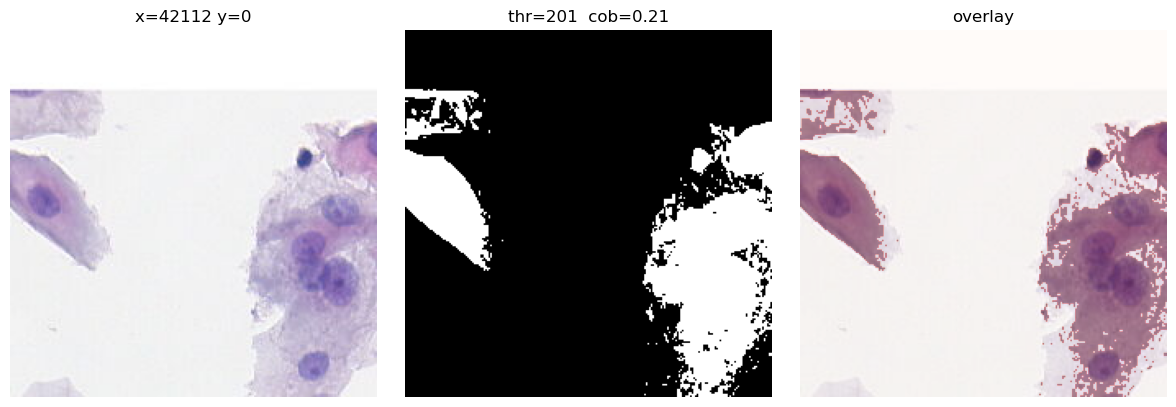

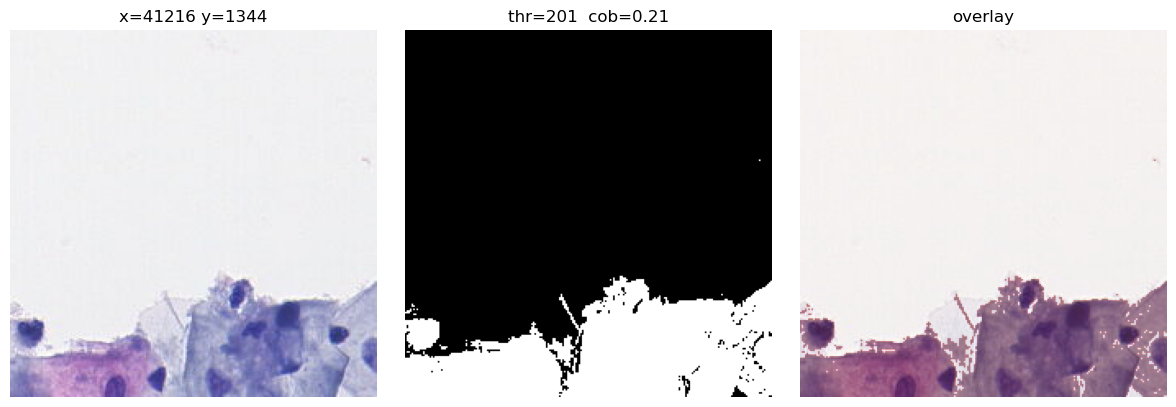

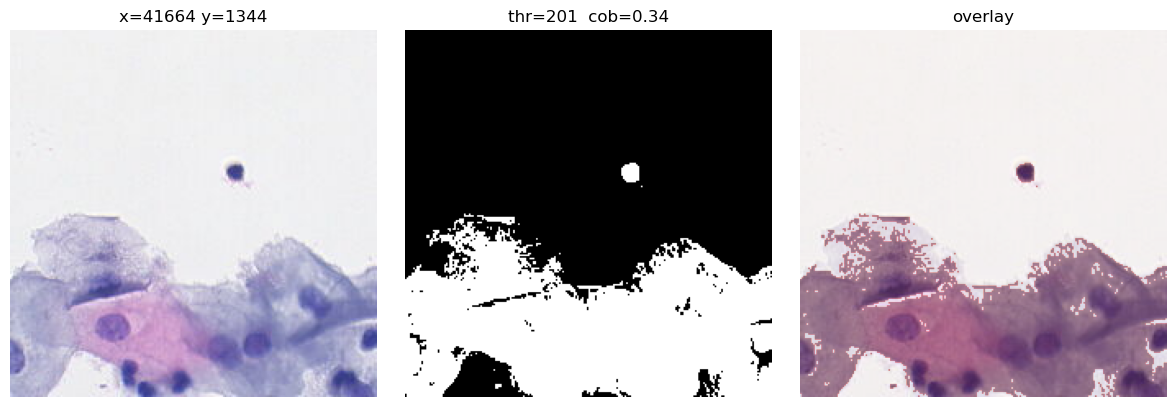

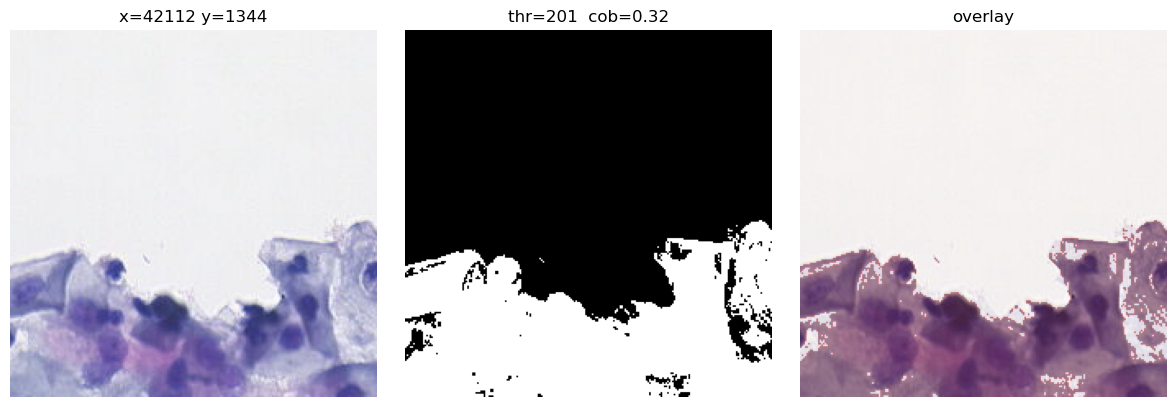

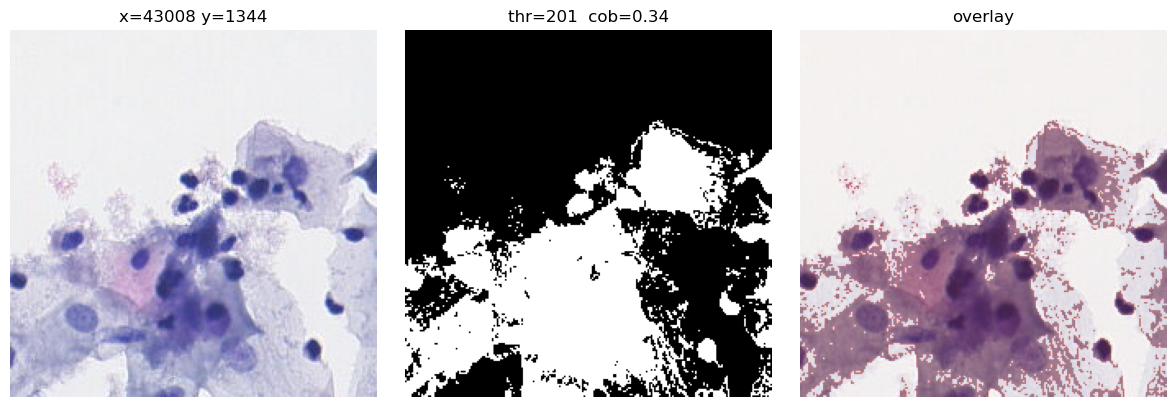

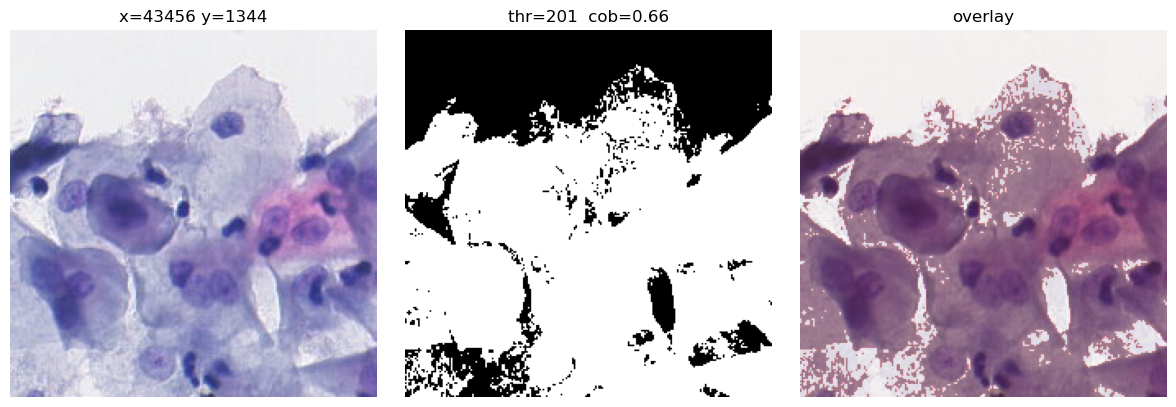

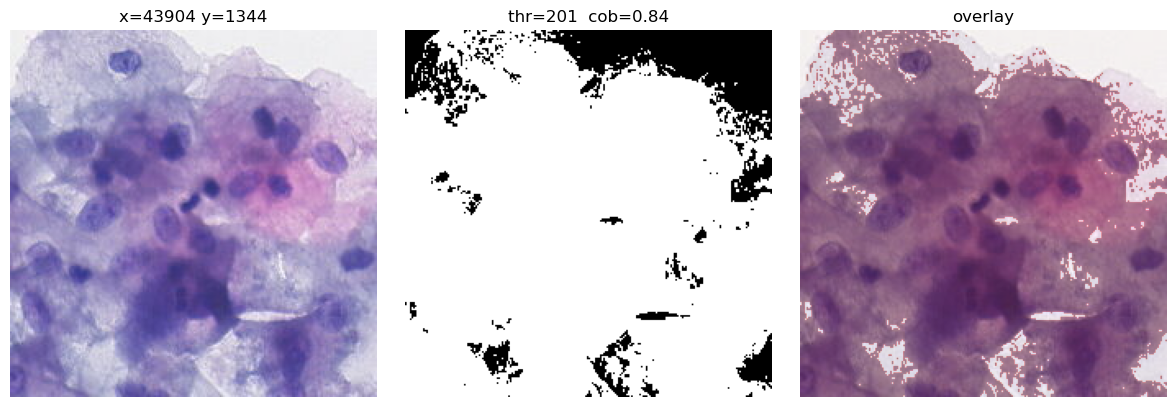

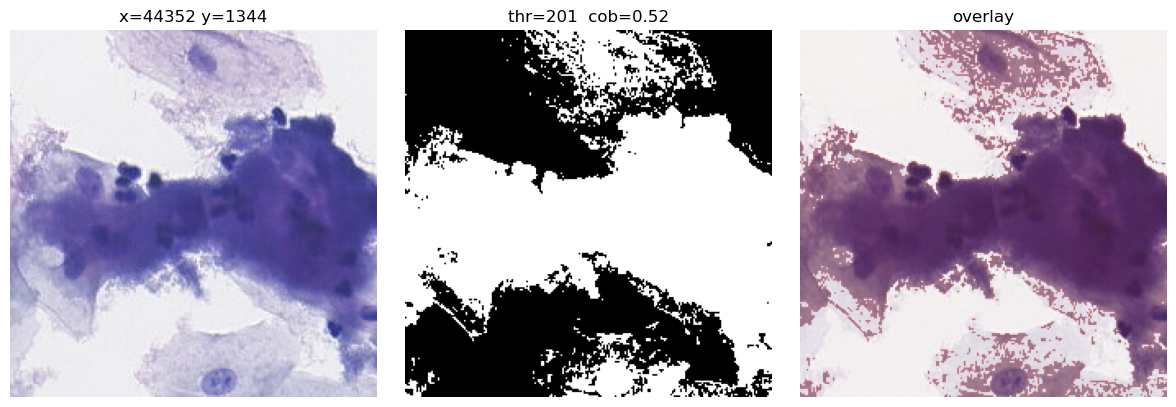

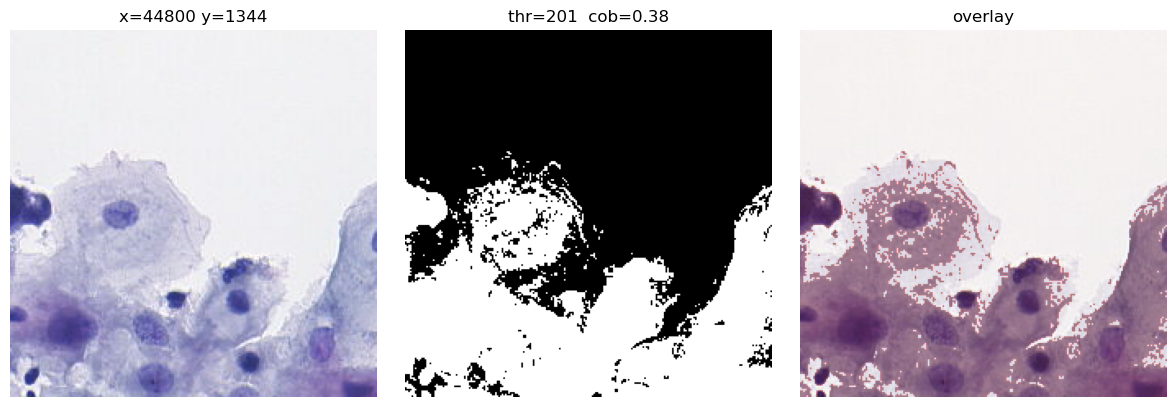

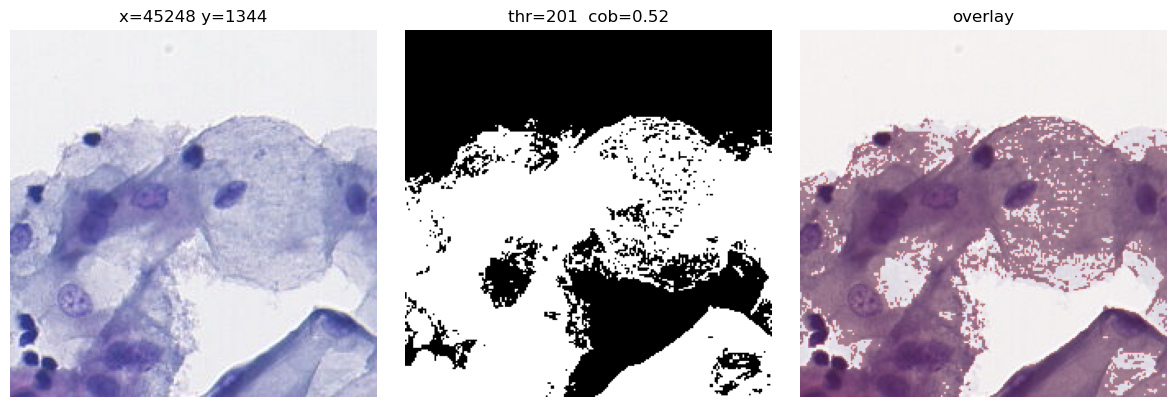

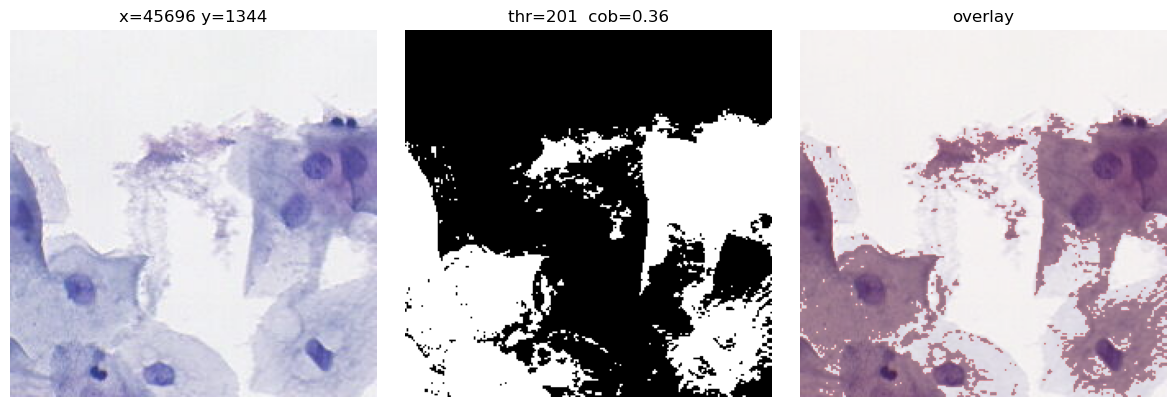

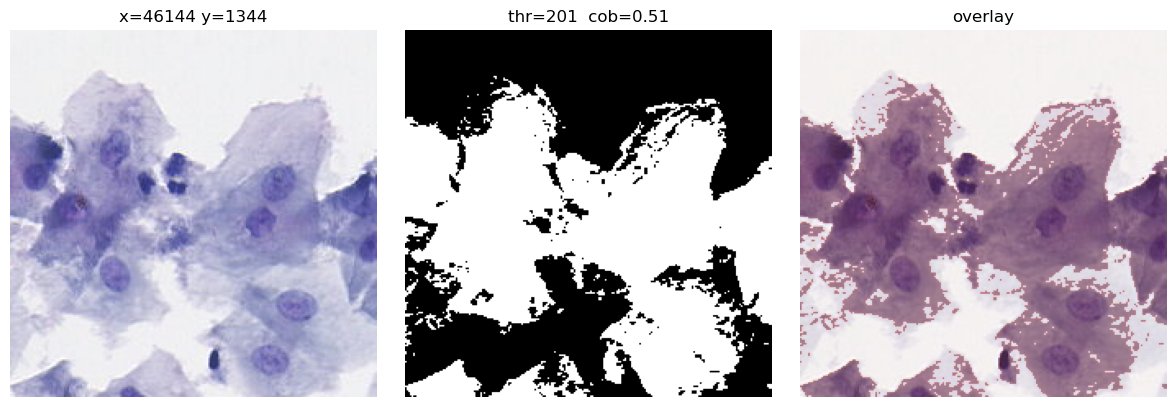

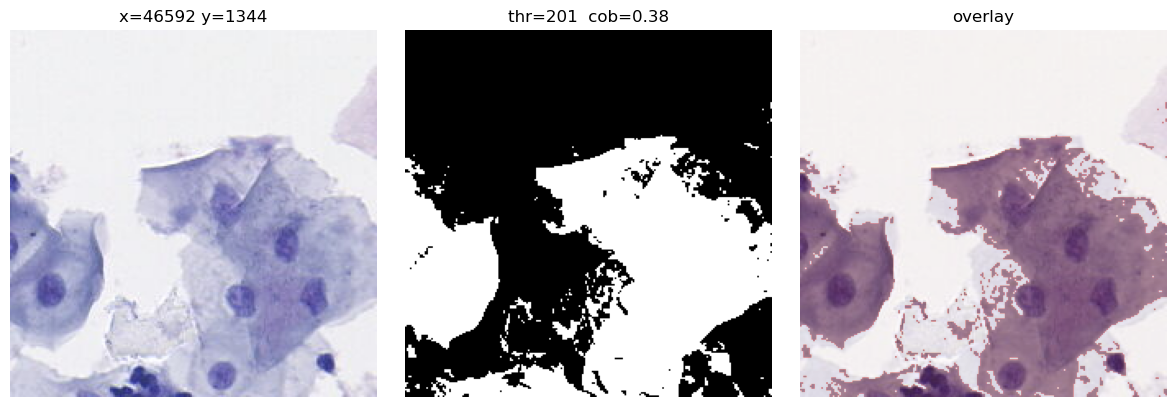

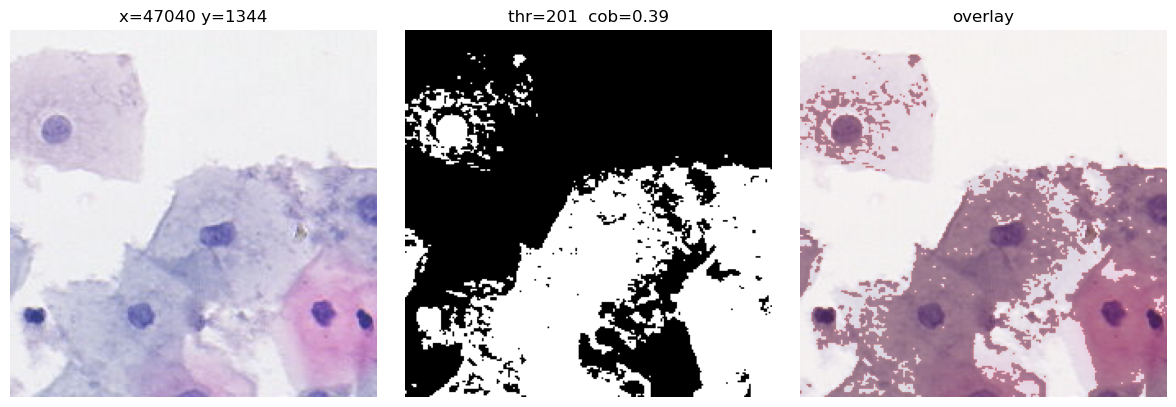

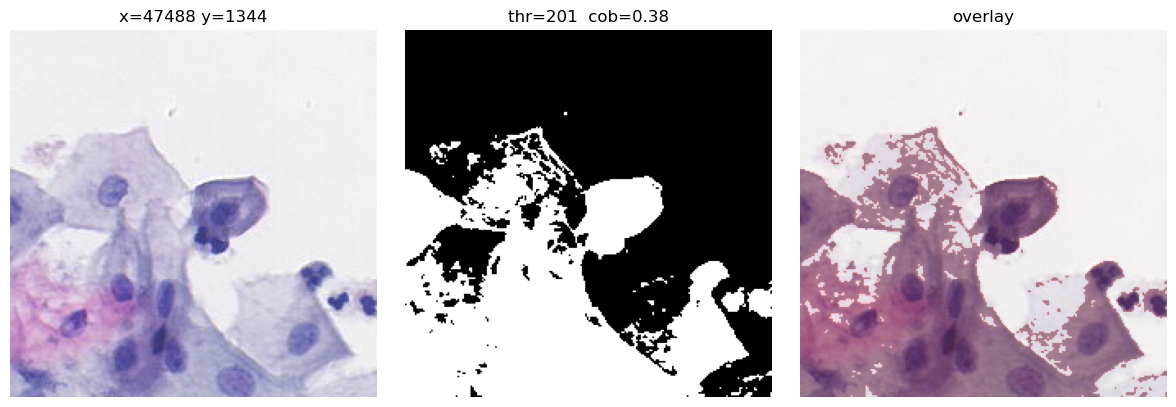

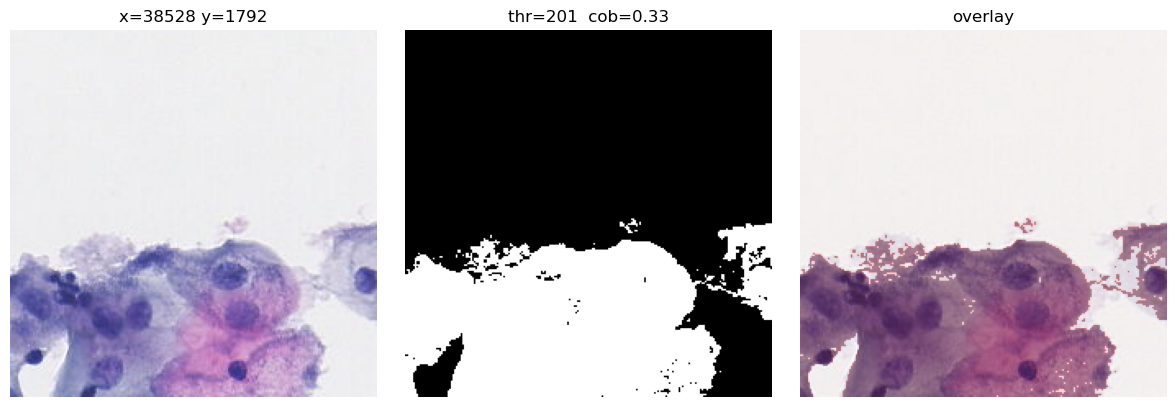

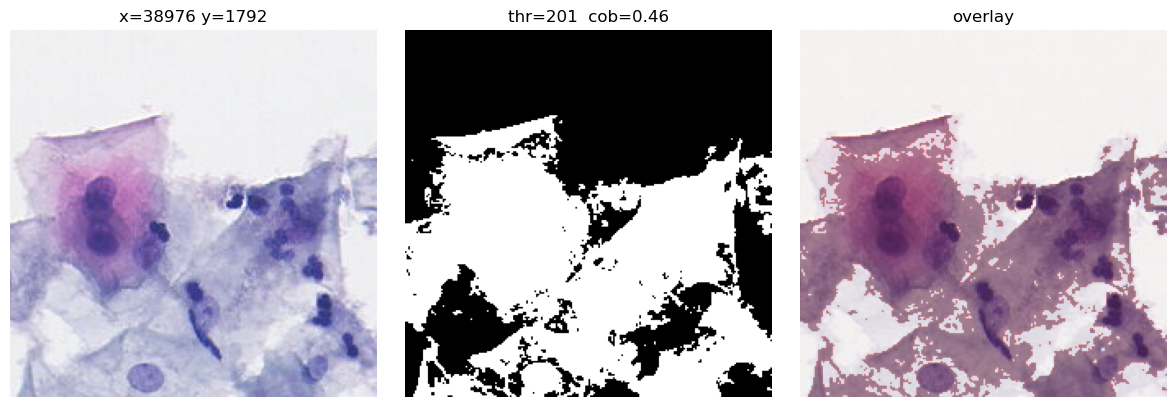

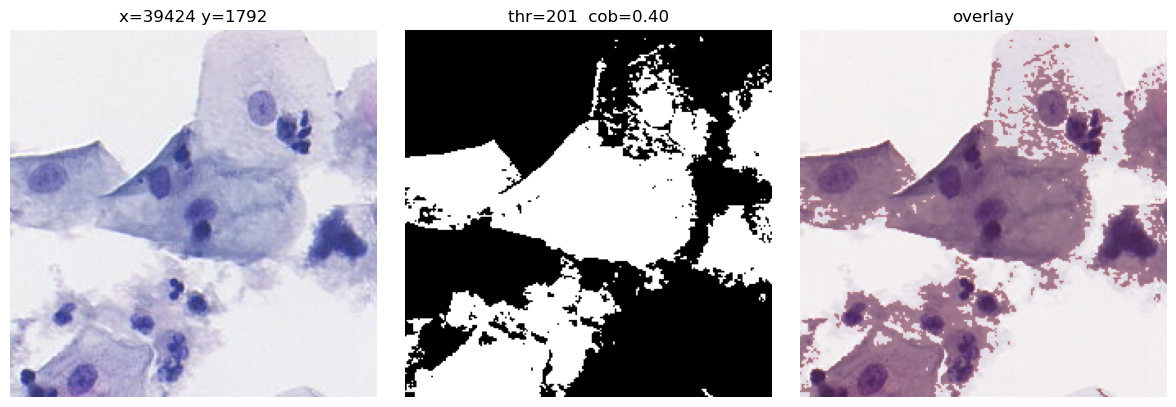

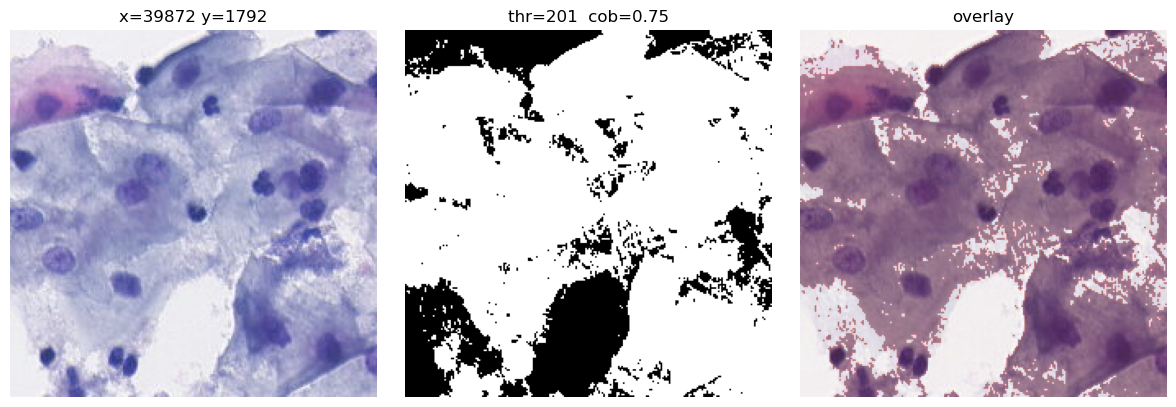

In [15]:
show = 0
for y in range(0, H-step+1, step):
    for x in range(0, W-step+1, step):

        region = s.read_region((x, y), level, (tile_size, tile_size))
        if np.asarray(region)[..., 3].min() == 0:
            continue
        img = region.convert("RGB")
        
        gray = np.asarray(img.convert("L"))
        mask = gray < thr

        cell_area = mask.sum()
        if (cell_area / total_area) < 0.20:
          continue

        show += 1
        if show >= 20:
          break

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].imshow(img); ax[0].set_title(f"x={x} y={y}")
        ax[1].imshow(mask, cmap="gray"); ax[1].set_title(f"thr={thr}  cob={mask.mean():.2f}")
        ax[2].imshow(img); ax[2].imshow(mask, cmap="Reds", alpha=0.35)
        ax[2].set_title("overlay")
        for a in ax: a.axis("off")
        plt.tight_layout(); plt.show()

    if show >= 20:
      break

## Contagem de tiles válidos na lâmina inteira (>20% conteúdo celular)

In [16]:
valid_tiles = 0
for y in range(0, H-step+1, step):
    for x in range(0, W-step+1, step):

        region = s.read_region((x, y), level, (tile_size, tile_size))
        if np.asarray(region)[..., 3].min() == 0:
            continue
        img = region.convert("RGB")
        
        gray = np.asarray(img.convert("L"))
        mask = gray < thr

        cell_area = mask.sum()
        if (cell_area / total_area) >= 0.20:
          valid_tiles += 1

print("[Tiles válidos]", valid_tiles)

[Tiles válidos] 8799


## Função para extração de tiles

In [20]:
def extract_tiles(slide_path, save_path, tile_size=224):
    # Abertura da lâmina e verificação de magnificação 20x
    s = kfbslide.OpenSlide(Path(slide_path))
    if int(s.properties.get("openslide.objective-power")) != 40:
        s.close()
        return
    if int(s.level_downsamples[1]) != 2:
        s.close()
        return

    # Otsu na lâmina toda (miniatura)
    lv_thumb = s.get_best_level_for_downsample(32)
    thumb = s.read_region((0, 0), lv_thumb, s.level_dimensions[lv_thumb]).convert("L")
    thr = threshold_otsu(np.asarray(thumb))
    total_area = tile_size * tile_size

    # Pasta de saída
    out_dir = Path(save_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Extração de tiles
    level = 1
    step = tile_size * 2
    W, H = s.dimensions
    count = 0
    for y in range(0, H-step+1, step):
        for x in range(0, W-step+1, step):
    
            region = s.read_region((x, y), level, (tile_size, tile_size))
            if np.asarray(region)[..., 3].min() == 0:
                continue
            img = region.convert("RGB")
                
            gray = np.asarray(img.convert("L"))
            mask = gray < thr
    
            cell_area = mask.sum()
            if (cell_area / total_area) < 0.20:
              continue

            # Evita tiles 'sujos'
            px = np.asarray(img)[mask].reshape(-1, 1, 3)
            if np.median(rgb2hsv(px / 255.0)[..., 0]) * 360 < 180:
              continue

            img.save(out_dir / (str(count) + ".png"))
            count += 1

    s.close()

In [21]:
# Teste
import openslide, kfbslide
import numpy as np
import time
from pathlib import Path
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv

slides = ["2024-10-14_08_23_14CYT","2024-10-14_08_29_15CYT","2024-10-14_08_32_03CYT","2024-10-14_08_34_52CYT",
         "2024-10-14_08_37_27CYT","2024-10-14_08_40_20CYT"]

for slide_name in slides:
    start = time.perf_counter()
    extract_tiles(slide_path=rf"D:\{slide_name}.kfb", save_path=rf"D:\slides\{slide_name}")
    end = time.perf_counter()
    
    print(f"Tempo de extração: {end - start:.4f} segundos [{slide_name}]")

Tempo de extração: 78.4959 segundos [2024-10-14_08_23_14CYT]
Tempo de extração: 60.9476 segundos [2024-10-14_08_29_15CYT]
Tempo de extração: 212.3034 segundos [2024-10-14_08_32_03CYT]
Tempo de extração: 78.3495 segundos [2024-10-14_08_34_52CYT]
Tempo de extração: 65.5630 segundos [2024-10-14_08_37_27CYT]
Tempo de extração: 176.9375 segundos [2024-10-14_08_40_20CYT]
